## How well do jobs and skills pay for Data Analysts?

#### Methodology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_INA = df[df['job_country'] == 'Indonesia'].dropna(subset=['salary_year_avg'])

In [3]:
job_titles = df_INA['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Business Analyst',
 'Senior Data Analyst',
 'Machine Learning Engineer']

In [4]:
df_INA_top6 = df_INA[df_INA['job_title_short'].isin(job_titles)] 

In [5]:
job_order =df_INA_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_order

Index(['Data Engineer', 'Machine Learning Engineer', 'Senior Data Analyst',
       'Data Scientist', 'Data Analyst', 'Business Analyst'],
      dtype='object', name='job_title_short')

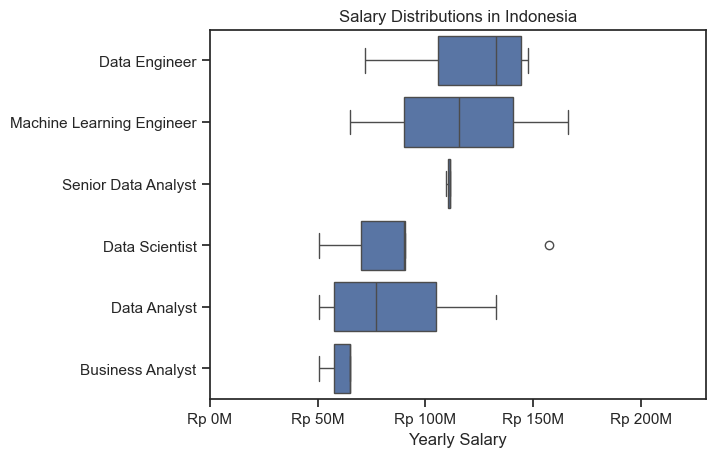

In [58]:
sns.boxplot(data=df_INA_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distributions in Indonesia')
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.xlim(0,230000)

ticks_x = plt.FuncFormatter(lambda y, pos: f'Rp {int(y/1000)}M')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

In [13]:
df_DA_INA = df[(df['job_country'] == 'Indonesia') & (df['job_title_short'] == 'Data Analyst')].copy()

df_DA_INA = df_DA_INA.dropna(subset=['salary_year_avg'])

In [14]:
df_DA_INA = df_DA_INA.explode('job_skills')

df_DA_INA[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
229531,105000.0,excel
239163,102500.0,sql
239163,102500.0,excel
303696,57500.0,r
343560,57500.0,python


In [ ]:
df_DA_top_pay = df_DA_INA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
power bi,1,132500.00
javascript,1,132500.00
tableau,3,105000.00
looker,1,105000.00
sql,9,100500.00
excel,6,89758.75
aws,1,77017.50
python,8,76042.50
r,3,75067.50


In [64]:
df_DA_skills = df_DA_INA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
power bi,1,132500.00
tableau,3,105000.00
sql,9,100500.00
excel,6,89758.75
python,8,76042.50
r,3,75067.50
sql server,1,64800.00
bigquery,3,57500.00
asana,1,57500.00


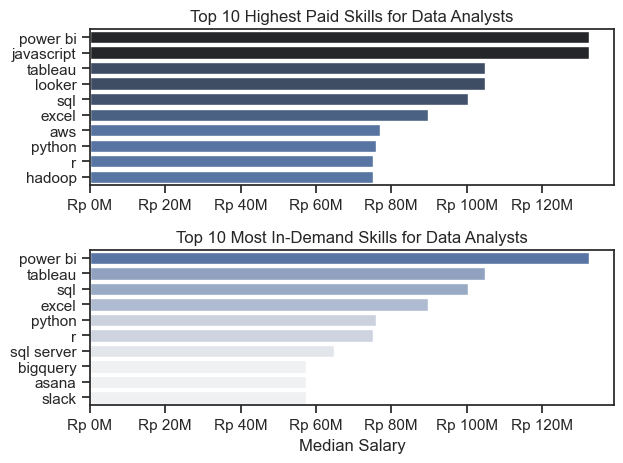

In [62]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

# top 10 Highest Paid Skills for Data Analyst
sns.barplot(data=df_DA_top_pay, ax=ax[0], x='median', y=df_DA_top_pay.index, hue='median', palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'Rp {int(x/1000)}M'))

# top 10 Most In-Demand Skills for Data Analyst
sns.barplot(data=df_DA_skills, ax=ax[1], x='median', y=df_DA_skills.index, hue='median', palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_xlabel('Median Salary')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'Rp {int(x/1000)}M'))

plt.tight_layout()
plt.show()